# 07 — Exploration:  *what does each encoder actually group by?*

**Purpose.** A standalone, additive notebook — it does **not** modify
`02_Embeddings/` or `03_Final_Results/` and does not depend on rerunning
notebooks 02–06.  Every run writes to a fresh timestamped subfolder of
`Explorations/`.

**Inputs (read-only):**
  - `01_Processed_Data/metadata.csv`
  - `01_Processed_Data/audio/*.wav`
  - `02_Embeddings/*.npy`     (the six original embedding sets from nb02–04)

**Outputs per run** (written to `Explorations/run_YYYY-MM-DD_HH-MM/`):
  - `embeddings/`             — four NEW audio embedding sets (random + energy-peak × IB + MERT)
  - `embeddings/labels.csv`   — five alternative labelings used by methods 1–5
  - `results/`                — CSVs from each of the five analyses
  - `figures/`                — ~12 PNGs
  - `summary.md`              — short markdown writeup of the top findings

**The five analyses** (run on the original 6 spaces *and* the 4 newly resampled
audio spaces — 10 encoder-spaces total):
1. K-means in each space, then per-cluster purity by every label scheme.
2. Per-track top-K nearest neighbors per encoder + 5 diagnostic-track listings.
3. Silhouette by alternative labelings — bar chart + heatmap.
4. Cross-encoder neighbor-Jaccard maps — finds tracks each encoder uniquely sees.
5. Block-sorted 150×150 similarity heatmaps per label scheme.

**Design notes.**
  - Every cell is **defensively re-importable** so a Colab kernel restart in the
    middle of the notebook does not break later cells.
  - Random seed pinned (default `SEED=42`) for reproducibility within a run; vary
    `SEED` between runs if you want a Monte-Carlo estimate of the random-K-mean
    audio embedding.
  - All cosine math L2-normalizes its inputs first; ImageBind/MERT raw outputs
    are **not** unit-norm.


In [1]:
# === CELL 1 — Drive mount + create timestamped Explorations/run folder ===
from google.colab import drive
import os
from datetime import datetime
from pathlib import Path

drive.mount('/content/drive', force_remount=False)

# --- canonical project paths (match nb01–06) -----------------------------
PROJECT_ROOT  = "/content/drive/MyDrive/DL_Project_2026"
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "01_Processed_Data")
EMBED_DIR     = os.path.join(PROJECT_ROOT, "02_Embeddings")
RESULTS_DIR   = os.path.join(PROJECT_ROOT, "03_Final_Results")
EXPLORE_ROOT  = os.path.join(PROJECT_ROOT, "Explorations")

# --- create per-run subfolder ---------------------------------------------
RUN_STAMP   = datetime.now().strftime("%Y-%m-%d_%H-%M")
RUN_DIR     = os.path.join(EXPLORE_ROOT, f"run_{RUN_STAMP}")
EMB_OUT     = os.path.join(RUN_DIR, "embeddings")
RES_OUT     = os.path.join(RUN_DIR, "results")
FIG_OUT     = os.path.join(RUN_DIR, "figures")
for d in (EMB_OUT, RES_OUT, FIG_OUT):
    os.makedirs(d, exist_ok=True)

# --- contract assertions: project skeleton must exist ---------------------
assert os.path.isdir(PROCESSED_DIR), f"Missing {PROCESSED_DIR} — run nb01 first."
assert os.path.isdir(EMBED_DIR),     f"Missing {EMBED_DIR} — run nb02–04 first."

NOTEBOOK_ID = "07"
SEED = 18

print(f"📁  Run folder:        {RUN_DIR}")
print(f"📁  Read embeddings:   {EMBED_DIR}")
print(f"📁  Read processed:    {PROCESSED_DIR}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁  Run folder:        /content/drive/MyDrive/DL_Project_2026/Explorations/run_2026-05-05_14-38
📁  Read embeddings:   /content/drive/MyDrive/DL_Project_2026/02_Embeddings
📁  Read processed:    /content/drive/MyDrive/DL_Project_2026/01_Processed_Data


In [2]:
# === CELL 2 — Imports + small utilities ===
# Defensive re-import block so this cell can be re-run after a kernel restart.
import os, json, math, time, warnings, random
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import normalize
from sklearn.neighbors import NearestNeighbors
warnings.filterwarnings("ignore")

# Reproducibility
np.random.seed(SEED); random.seed(SEED)

# Tiny helpers ------------------------------------------------------------
def l2(X):
    """Row-wise L2-normalize (safe)."""
    return normalize(X.astype(np.float32), norm="l2", axis=1)

def cos_sim(A, B=None):
    """Cosine similarity. If B is None, computes A vs A."""
    A = l2(A); B = l2(B) if B is not None else A
    return A @ B.T

def topk_neighbors(X, k=5, exclude_self=True):
    """For each row of X, return indices of its top-k cosine neighbors."""
    sim = cos_sim(X)
    if exclude_self:
        np.fill_diagonal(sim, -np.inf)
    return np.argsort(-sim, axis=1)[:, :k]

def jaccard_top(setA, setB):
    """Jaccard between two top-k neighbor sets (tuples of int)."""
    a, b = set(setA), set(setB)
    return len(a & b) / max(1, len(a | b))

def cluster_purity(labels_pred, labels_true):
    """Standard purity. Both 1-D int arrays of equal length."""
    from collections import Counter
    total = len(labels_pred); correct = 0
    for c in np.unique(labels_pred):
        members = labels_true[labels_pred == c]
        if len(members) == 0: continue
        most_common = Counter(members).most_common(1)[0][1]
        correct += most_common
    return correct / total

print("✅ utilities ready")


✅ utilities ready


In [3]:
# === CELL 3 — Metadata + alternative label schemes ===
import os, re, pandas as pd, numpy as np
metadata = pd.read_csv(os.path.join(PROCESSED_DIR, "metadata.csv"))
N = len(metadata)
assert N == 150, f"Expected 150 tracks, got {N}"

# --- 1. Emotion (already in metadata) -----------------------------------
metadata["label_emotion"] = metadata["emotion_category"]

# --- 2. Subcategory (already in metadata) -------------------------------
metadata["label_subcategory"] = metadata["emotion_subcategory"]

# --- 3. Contributor (already in metadata) -------------------------------
metadata["label_contributor"] = metadata["contributor"]

# --- 4. Genre top-level (parse text BEFORE the first '/' or '[') --------
def parse_genre_top(g):
    if not isinstance(g, str) or not g.strip():
        return "Unknown"
    s = g.strip()
    # split on '[' first to drop sub-genre brackets, then on '/' for top family
    s = s.split("[")[0].strip()
    s = s.split("/")[0].strip()
    return s if s else "Unknown"
metadata["label_genre_top"] = metadata["genre"].apply(parse_genre_top)

# --- 5. Vocal-vs-instrumental — derived from lyrics file content --------
def has_vocal(lyric_rel_path):
    full = os.path.join(PROJECT_ROOT, lyric_rel_path) if isinstance(lyric_rel_path, str) else None
    if not full or not os.path.exists(full):
        return "instrumental"
    try:
        with open(full, "r", encoding="utf-8", errors="ignore") as f:
            txt = f.read().strip()
        return "vocal" if len(txt) > 50 else "instrumental"
    except Exception:
        return "vocal"
metadata["label_vocal"] = metadata["lyrics_path"].apply(has_vocal)

# --- 6. Audio-duration bucket (computed from .wav files) -----------------
import wave, contextlib
def wav_seconds(rel_path):
    full = os.path.join(PROJECT_ROOT, rel_path) if isinstance(rel_path, str) else None
    if not full or not os.path.exists(full):
        return np.nan
    try:
        with contextlib.closing(wave.open(full, "rb")) as w:
            return w.getnframes() / float(w.getframerate())
    except Exception:
        return np.nan
metadata["audio_seconds"] = metadata["standardized_audio_path"].apply(wav_seconds)
def dur_bucket(s):
    if pd.isna(s): return "unknown"
    if s < 150: return "short(<2.5min)"
    if s < 240: return "medium(2.5-4min)"
    return "long(>4min)"
metadata["label_duration_bucket"] = metadata["audio_seconds"].apply(dur_bucket)

LABEL_COLS = [
    "label_emotion", "label_subcategory", "label_contributor",
    "label_genre_top", "label_vocal", "label_duration_bucket",
]

# Save the labels file for downstream traceability
labels_path = os.path.join(EMB_OUT, "labels.csv")
metadata[["track_id","song_title","artist_name"] + LABEL_COLS].to_csv(labels_path, index=False)

# Print summary
print("Label scheme value counts:")
for col in LABEL_COLS:
    n_unique = metadata[col].nunique()
    print(f"  {col:30s}  {n_unique:3d} levels")
print(f"\n💾 saved {labels_path}")


Label scheme value counts:
  label_emotion                     6 levels
  label_subcategory                24 levels
  label_contributor                 5 levels
  label_genre_top                  11 levels
  label_vocal                       1 levels
  label_duration_bucket             1 levels

💾 saved /content/drive/MyDrive/DL_Project_2026/Explorations/run_2026-05-05_14-38/embeddings/labels.csv


In [4]:
# === CELL 4 — Load the SIX original embedding sets from nb02–04 ===
import os, numpy as np

ORIGINAL_FILES = {
    "audio_ib_orig":   "audio_ib_embeddings.npy",
    "audio_mert_orig": "audio_embeddings_MERT.npy",
    "image_ib":        "image_ib_embeddings.npy",
    "image_clip":      "image_clip_embeddings.npy",
    "text_ib":         "text_ib_embeddings.npy",
    "text_clap":       "text_clap_embeddings.npy",
}

ORIG_EMB = {}
for name, fname in ORIGINAL_FILES.items():
    p = os.path.join(EMBED_DIR, fname)
    assert os.path.exists(p), f"Missing {p} — run nb02–04 first."
    arr = np.load(p)
    assert arr.shape[0] == 150, f"{fname} has {arr.shape[0]} rows, expected 150"
    ORIG_EMB[name] = arr.astype(np.float32)
    print(f"  {name:18s}  {arr.shape}  dtype={arr.dtype}")


  audio_ib_orig       (150, 1024)  dtype=float32
  audio_mert_orig     (150, 768)  dtype=float32
  image_ib            (150, 1024)  dtype=float32
  image_clip          (150, 512)  dtype=float32
  text_ib             (150, 1024)  dtype=float32
  text_clap           (150, 512)  dtype=float32


In [5]:
# === CELL 5 — Install + load ImageBind & MERT (skip if you don't re-extract) ===
# This cell is heavy (~3-4 min on a fresh Colab). Skip if RUN_REEXTRACT = False.

RUN_REEXTRACT = True   # toggle to False if you only want analysis on original embeddings

if RUN_REEXTRACT:
    import sys, subprocess, importlib

    def pip_q(args):
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + args)

    try:
        import imagebind, transformers, torchaudio  # noqa
    except Exception:
        print("📦 installing ImageBind + transformers + torchaudio + librosa ...")
        pip_q(["git+https://github.com/facebookresearch/ImageBind.git"])
        pip_q(["transformers", "torchaudio", "librosa"])

    import torch, torchaudio
    import torchaudio.transforms as T
    from imagebind import data as ib_data
    from imagebind.models import imagebind_model
    from imagebind.models.imagebind_model import ModalityType
    from transformers import AutoModel, Wav2Vec2FeatureExtractor

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"🖥️  device: {DEVICE}")

    print("🧠 loading ImageBind huge ...")
    IB_MODEL = imagebind_model.imagebind_huge(pretrained=True).to(DEVICE).eval()

    print("🎸 loading MERT-v1-95M ...")
    MERT_MODEL = AutoModel.from_pretrained(
        "m-a-p/MERT-v1-95M", trust_remote_code=True
    ).to(DEVICE).eval()
    MERT_PROC = Wav2Vec2FeatureExtractor.from_pretrained(
        "m-a-p/MERT-v1-95M", trust_remote_code=True
    )
    MERT_SR = MERT_PROC.sampling_rate    # 24_000
    print("✅ models loaded")
else:
    print("ℹ️  RUN_REEXTRACT is False — Cells 6–7 will reuse only the original embeddings.")


🖥️  device: cuda
🧠 loading ImageBind huge ...
🎸 loading MERT-v1-95M ...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

✅ models loaded


In [6]:
# === CELL 6 — Re-extract AUDIO with two new sampling methods ===
# RANDOM-K-mean : K random 2-second windows, mean-pool the K embeddings
# ENERGY-PEAK   : K windows around the K highest-RMS-energy moments
#
# We re-extract with BOTH ImageBind audio and MERT, giving 4 new embedding sets.
# Image and text are not re-extracted — sampling matters only for audio.

if RUN_REEXTRACT:
    import os, numpy as np, torch, torchaudio
    import librosa
    import tempfile, soundfile as sf
    from pathlib import Path

    K_CLIPS  = 5      # number of clips per track for both methods
    CLIP_SEC = 2.0    # seconds per clip — matches ImageBind's expected audio length
    MERT_CLIP_SEC = 10.0  # MERT can take longer, gives richer per-clip rep
    HOP_SEC  = 0.5    # for energy peak detection

    audio_paths = [
        os.path.join(PROJECT_ROOT, p)
        for p in metadata["standardized_audio_path"].tolist()
    ]

    # ---- helper: pick energy-peak start times ---------------------------
    def peak_starts(wav_np, sr, n_peaks, clip_sec):
        """Return n_peaks distinct start-time offsets (seconds) at local RMS maxima.
        wav_np 1-D mono float32. Falls back to evenly spaced if too few peaks."""
        frame = int(0.05 * sr)               # 50 ms frame
        hop   = int(HOP_SEC * sr)
        rms = librosa.feature.rms(y=wav_np, frame_length=frame, hop_length=hop)[0]
        # keep only candidates with at least clip_sec of audio after them
        max_start_frame = max(1, len(rms) - int(clip_sec / HOP_SEC))
        rms = rms[:max_start_frame]
        if len(rms) <= n_peaks:
            return np.linspace(0, max(0, len(wav_np)/sr - clip_sec), n_peaks)
        order = np.argsort(-rms)
        chosen = []
        for idx in order:
            t = idx * HOP_SEC
            if all(abs(t - c) > clip_sec for c in chosen):
                chosen.append(t)
            if len(chosen) == n_peaks: break
        if len(chosen) < n_peaks:
            extra = np.linspace(0, max(0, len(wav_np)/sr - clip_sec), n_peaks - len(chosen))
            chosen.extend(extra.tolist())
        return np.array(chosen[:n_peaks])

    def random_starts(wav_np, sr, n_clips, clip_sec, rng):
        max_start = max(0.0, len(wav_np)/sr - clip_sec)
        return rng.uniform(0, max_start, size=n_clips) if max_start > 0 else np.zeros(n_clips)

    def write_temp_wav(wav_np, sr, out_path):
        sf.write(out_path, wav_np, sr, subtype="PCM_16")

    # ---- ImageBind sampler --------------------------------------------------
    def ib_embed_clips(wav_path, starts, clip_sec=CLIP_SEC):
        """Slice wav into clips of length clip_sec at the given start offsets,
        write to temp files, run ImageBind on the batch, return mean embedding."""
        wav, sr = librosa.load(wav_path, sr=16000, mono=True)  # IB expects 16k
        embs = []
        with tempfile.TemporaryDirectory() as tmpdir:
            tmp_paths = []
            for i, t in enumerate(starts):
                a = int(t * sr); b = a + int(clip_sec * sr)
                clip = wav[a:b]
                if len(clip) < int(clip_sec * sr):     # pad if short
                    clip = np.pad(clip, (0, int(clip_sec * sr) - len(clip)))
                tp = os.path.join(tmpdir, f"clip_{i}.wav")
                write_temp_wav(clip, sr, tp)
                tmp_paths.append(tp)
            batch = ib_data.load_and_transform_audio_data(tmp_paths, DEVICE)
            with torch.no_grad():
                out = IB_MODEL({ModalityType.AUDIO: batch})
            embs = out[ModalityType.AUDIO].detach().cpu().numpy().astype(np.float32)
        return embs.mean(axis=0)   # (1024,)

    # ---- MERT sampler -------------------------------------------------------
    def mert_embed_clips(wav_path, starts, clip_sec=MERT_CLIP_SEC):
        wav_t, sr = torchaudio.load(wav_path)
        if wav_t.shape[0] > 1: wav_t = wav_t.mean(0, keepdim=True)
        if sr != MERT_SR:
            wav_t = torchaudio.transforms.Resample(sr, MERT_SR)(wav_t)
            sr = MERT_SR
        wav_np = wav_t.squeeze().numpy()
        per_clip_emb = []
        for t in starts:
            a = int(t * sr); b = a + int(clip_sec * sr)
            clip = wav_np[a:b]
            if len(clip) < int(0.5 * sr):       # too short to be useful
                continue
            inp = MERT_PROC(clip, sampling_rate=MERT_SR, return_tensors="pt")
            inp = {k: v.to(DEVICE) for k, v in inp.items()}
            with torch.no_grad():
                out = MERT_MODEL(**inp, output_hidden_states=True)
            layers = torch.stack(out.hidden_states).squeeze(1)
            time_mean  = layers.mean(dim=1)
            layer_mean = time_mean.mean(dim=0)
            per_clip_emb.append(layer_mean.cpu().numpy().astype(np.float32))
        if not per_clip_emb:
            # fallback: full-track embedding
            inp = MERT_PROC(wav_np, sampling_rate=MERT_SR, return_tensors="pt")
            inp = {k: v.to(DEVICE) for k, v in inp.items()}
            with torch.no_grad():
                out = MERT_MODEL(**inp, output_hidden_states=True)
            layers = torch.stack(out.hidden_states).squeeze(1)
            return layers.mean(dim=1).mean(dim=0).cpu().numpy().astype(np.float32)
        return np.stack(per_clip_emb).mean(axis=0)

    rng = np.random.default_rng(SEED)

    audio_ib_random   = np.zeros((N, 1024), dtype=np.float32)
    audio_ib_energy   = np.zeros((N, 1024), dtype=np.float32)
    audio_mert_random = np.zeros((N,  768), dtype=np.float32)
    audio_mert_energy = np.zeros((N,  768), dtype=np.float32)

    print(f"🎧 re-extracting (K={K_CLIPS} clips · {CLIP_SEC}s IB · {MERT_CLIP_SEC}s MERT) ...")
    for i, wav_path in enumerate(audio_paths):
        # Load once for energy detection
        wav, sr = librosa.load(wav_path, sr=16000, mono=True)
        rnd = random_starts(wav, sr, K_CLIPS, CLIP_SEC, rng)
        peak = peak_starts(wav, sr, K_CLIPS, CLIP_SEC)

        # Same start-times for both encoders so methods are comparable
        # (but MERT uses LONGER clips around the same centers)
        rnd_mert  = np.clip(rnd  - (MERT_CLIP_SEC - CLIP_SEC) / 2, 0, None)
        peak_mert = np.clip(peak - (MERT_CLIP_SEC - CLIP_SEC) / 2, 0, None)

        audio_ib_random[i]   = ib_embed_clips(wav_path, rnd)
        audio_ib_energy[i]   = ib_embed_clips(wav_path, peak)
        audio_mert_random[i] = mert_embed_clips(wav_path, rnd_mert)
        audio_mert_energy[i] = mert_embed_clips(wav_path, peak_mert)

        if (i+1) % 10 == 0 or i == 0:
            print(f"   [{i+1:3d}/{N}]  {os.path.basename(wav_path)}")

    # Save
    np.save(os.path.join(EMB_OUT, "audio_ib_random.npy"),   audio_ib_random)
    np.save(os.path.join(EMB_OUT, "audio_ib_energy.npy"),   audio_ib_energy)
    np.save(os.path.join(EMB_OUT, "audio_mert_random.npy"), audio_mert_random)
    np.save(os.path.join(EMB_OUT, "audio_mert_energy.npy"), audio_mert_energy)

    # Validation
    for nm, arr in [("audio_ib_random", audio_ib_random),
                     ("audio_ib_energy", audio_ib_energy),
                     ("audio_mert_random", audio_mert_random),
                     ("audio_mert_energy", audio_mert_energy)]:
        assert arr.shape[0] == 150 and np.isfinite(arr).all(), nm
        print(f"  💾 {nm:20s} {arr.shape}")

    print("✅ re-extraction complete")
else:
    print("ℹ️  skipped re-extraction (RUN_REEXTRACT=False).  Cells below will use only original embeddings.")


🎧 re-extracting (K=5 clips · 2.0s IB · 10.0s MERT) ...
   [  1/150]  track_001.wav
   [ 10/150]  track_010.wav
   [ 20/150]  track_020.wav
   [ 30/150]  track_030.wav
   [ 40/150]  track_040.wav
   [ 50/150]  track_050.wav
   [ 60/150]  track_060.wav
   [ 70/150]  track_070.wav
   [ 80/150]  track_080.wav
   [ 90/150]  track_090.wav
   [100/150]  track_100.wav
   [110/150]  track_110.wav
   [120/150]  track_120.wav
   [130/150]  track_130.wav
   [140/150]  track_140.wav
   [150/150]  track_150.wav
  💾 audio_ib_random      (150, 1024)
  💾 audio_ib_energy      (150, 1024)
  💾 audio_mert_random    (150, 768)
  💾 audio_mert_energy    (150, 768)
✅ re-extraction complete


In [7]:
# === CELL 7 — Encoder zoo: dict {name: (N, D) array} for ALL spaces ===
import os, numpy as np

EMB = dict(ORIG_EMB)   # start with the 6 originals

NEW_AUDIO_FILES = [
    ("audio_ib_random",   "audio_ib_random.npy"),
    ("audio_ib_energy",   "audio_ib_energy.npy"),
    ("audio_mert_random", "audio_mert_random.npy"),
    ("audio_mert_energy", "audio_mert_energy.npy"),
]
for name, fname in NEW_AUDIO_FILES:
    p = os.path.join(EMB_OUT, fname)
    if os.path.exists(p):
        EMB[name] = np.load(p).astype(np.float32)

# Order so audio block stays grouped, then image, then text
ENCODERS = [
    "audio_ib_orig", "audio_ib_random", "audio_ib_energy",
    "audio_mert_orig", "audio_mert_random", "audio_mert_energy",
    "image_ib", "image_clip",
    "text_ib", "text_clap",
]
ENCODERS = [e for e in ENCODERS if e in EMB]

print(f"Encoder zoo  ({len(ENCODERS)} spaces):")
for e in ENCODERS:
    print(f"  {e:22s}  {EMB[e].shape}")


Encoder zoo  (10 spaces):
  audio_ib_orig           (150, 1024)
  audio_ib_random         (150, 1024)
  audio_ib_energy         (150, 1024)
  audio_mert_orig         (150, 768)
  audio_mert_random       (150, 768)
  audio_mert_energy       (150, 768)
  image_ib                (150, 1024)
  image_clip              (150, 512)
  text_ib                 (150, 1024)
  text_clap               (150, 512)


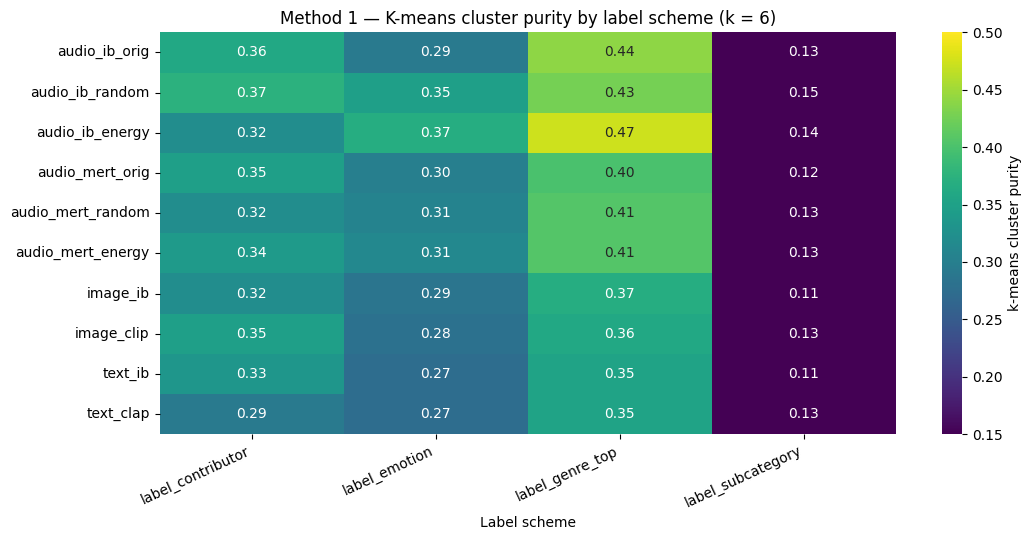

Best-purity label per encoder:
  audio_ib_orig          → label_contributor          purity=0.360  baseline=0.200  lift=+0.160
  audio_ib_random        → label_emotion              purity=0.347  baseline=0.167  lift=+0.180
  audio_ib_energy        → label_emotion              purity=0.367  baseline=0.167  lift=+0.200
  audio_mert_orig        → label_contributor          purity=0.347  baseline=0.200  lift=+0.147
  audio_mert_random      → label_emotion              purity=0.307  baseline=0.167  lift=+0.140
  audio_mert_energy      → label_emotion              purity=0.313  baseline=0.167  lift=+0.147
  image_ib               → label_emotion              purity=0.287  baseline=0.167  lift=+0.120
  image_clip             → label_contributor          purity=0.347  baseline=0.200  lift=+0.147
  text_ib                → label_contributor          purity=0.333  baseline=0.200  lift=+0.133
  text_clap              → label_emotion              purity=0.273  baseline=0.167  lift=+0.107


In [8]:
# === CELL 8 — METHOD 1: K-means in each space, purity by every label scheme ===
# For each encoder, run KMeans(k=6) on L2-normalized features, then for each
# label scheme compute cluster purity (the dominant-label fraction averaged
# over clusters, weighted by cluster size).
import os, numpy as np, pandas as pd

K = 6
rows = []
for enc in ENCODERS:
    Xn = l2(EMB[enc])
    km = KMeans(n_clusters=K, n_init=20, random_state=SEED).fit(Xn)
    pred = km.labels_
    for lab in LABEL_COLS:
        true = metadata[lab].astype("category").cat.codes.values
        if metadata[lab].nunique() < 2:
            continue
        pur = cluster_purity(pred, true)
        # also baseline: most-frequent-label purity (chance for a single-cluster predictor)
        bp = metadata[lab].value_counts(normalize=True).iloc[0]
        rows.append({"encoder": enc, "label": lab,
                     "kmeans_purity": round(pur, 4),
                     "majority_baseline": round(bp, 4),
                     "lift_over_baseline": round(pur - bp, 4)})

m1 = pd.DataFrame(rows)
m1_pivot = m1.pivot(index="encoder", columns="label", values="kmeans_purity").loc[ENCODERS]
m1.to_csv(os.path.join(RES_OUT, "method1_kmeans_purity.csv"), index=False)

# heatmap fig
import matplotlib.pyplot as plt, seaborn as sns
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.heatmap(m1_pivot, annot=True, fmt=".2f", cmap="viridis",
            cbar_kws={"label": "k-means cluster purity"}, ax=ax,
            vmin=0.15, vmax=max(0.5, m1_pivot.values.max()))
ax.set_title("Method 1 — K-means cluster purity by label scheme (k = 6)")
ax.set_ylabel(""); ax.set_xlabel("Label scheme")
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
fig.savefig(os.path.join(FIG_OUT, "method1_purity_heatmap.png"), dpi=150)
plt.show()

# Best-label per encoder summary
print("Best-purity label per encoder:")
for enc in ENCODERS:
    sub = m1[m1.encoder == enc].sort_values("lift_over_baseline", ascending=False)
    if not sub.empty:
        top = sub.iloc[0]
        print(f"  {enc:22s} → {top.label:25s}  purity={top.kmeans_purity:.3f}  "
              f"baseline={top.majority_baseline:.3f}  lift={top.lift_over_baseline:+.3f}")


In [9]:
# === CELL 9 — METHOD 2: Per-track nearest neighbors per encoder ===
import os, pandas as pd, numpy as np

K_NEIGHBORS = 5
DIAGNOSTIC_TRACKS = ["track_088", "track_027", "track_143", "track_055", "track_148"]
# m.A.A.d city, Bloom, Water, Hard Times, Wicked Game

tid2idx = {t: i for i, t in enumerate(metadata["track_id"])}
neighbors_full = []
diagnostic_lines = []

for enc in ENCODERS:
    nn = topk_neighbors(EMB[enc], k=K_NEIGHBORS, exclude_self=True)
    for i, row in enumerate(nn):
        for rank, j in enumerate(row, start=1):
            neighbors_full.append({
                "encoder": enc,
                "query_track": metadata.iloc[i]["track_id"],
                "query_song":  metadata.iloc[i]["song_title"],
                "query_emotion": metadata.iloc[i]["label_emotion"],
                "query_genre_top": metadata.iloc[i]["label_genre_top"],
                "rank": rank,
                "neighbor_track": metadata.iloc[j]["track_id"],
                "neighbor_song":  metadata.iloc[j]["song_title"],
                "neighbor_emotion": metadata.iloc[j]["label_emotion"],
                "neighbor_genre_top": metadata.iloc[j]["label_genre_top"],
                "same_emotion": metadata.iloc[j]["label_emotion"] == metadata.iloc[i]["label_emotion"],
                "same_genre":   metadata.iloc[j]["label_genre_top"] == metadata.iloc[i]["label_genre_top"],
            })

m2 = pd.DataFrame(neighbors_full)
m2.to_csv(os.path.join(RES_OUT, "method2_neighbors_full.csv"), index=False)

# fraction-same-emotion per encoder (a proxy for "this encoder clusters by emotion")
agg = m2.groupby("encoder").agg(
    frac_same_emotion=("same_emotion", "mean"),
    frac_same_genre=("same_genre", "mean"),
).round(3).loc[ENCODERS]
print("\n=== Top-K neighbor agreement with EACH labeling per encoder ===")
print(agg.to_string())

# Diagnostic-track listings
diagnostic_lines.append("=" * 78)
diagnostic_lines.append("DIAGNOSTIC TRACKS — top-5 nearest neighbors per encoder")
diagnostic_lines.append("=" * 78)
for tid in DIAGNOSTIC_TRACKS:
    if tid not in tid2idx: continue
    i = tid2idx[tid]
    md = metadata.iloc[i]
    diagnostic_lines.append(f"\n▶ {tid}  '{md.song_title}' by {md.artist_name}")
    diagnostic_lines.append(f"   true emotion = {md.label_emotion}    genre = {md.label_genre_top}")
    for enc in ENCODERS:
        nbrs = topk_neighbors(EMB[enc], k=K_NEIGHBORS, exclude_self=True)[i]
        names = [f"{metadata.iloc[j].song_title[:20]} ({metadata.iloc[j].label_emotion[:8]}/"
                 f"{metadata.iloc[j].label_genre_top[:8]})"
                 for j in nbrs]
        diagnostic_lines.append(f"   {enc:22s} → " + " | ".join(names))

diag_path = os.path.join(RES_OUT, "method2_diagnostic_neighbors.txt")
with open(diag_path, "w") as f: f.write("\n".join(diagnostic_lines))
print(f"\n💾 saved {diag_path}")
print("\nFirst diagnostic track preview:")
print("\n".join(diagnostic_lines[3:18]))



=== Top-K neighbor agreement with EACH labeling per encoder ===
                   frac_same_emotion  frac_same_genre
encoder                                              
audio_ib_orig                  0.220            0.363
audio_ib_random                0.216            0.332
audio_ib_energy                0.233            0.343
audio_mert_orig                0.221            0.303
audio_mert_random              0.237            0.301
audio_mert_energy              0.233            0.295
image_ib                       0.191            0.300
image_clip                     0.188            0.307
text_ib                        0.188            0.241
text_clap                      0.199            0.233

💾 saved /content/drive/MyDrive/DL_Project_2026/Explorations/run_2026-05-05_14-38/results/method2_diagnostic_neighbors.txt

First diagnostic track preview:

▶ track_088  'm.A.A.d city' by Kendrick Lamar, MC Eiht
   true emotion = Tension, Threat & Aggression    genre = Hip-Hop
   audio_

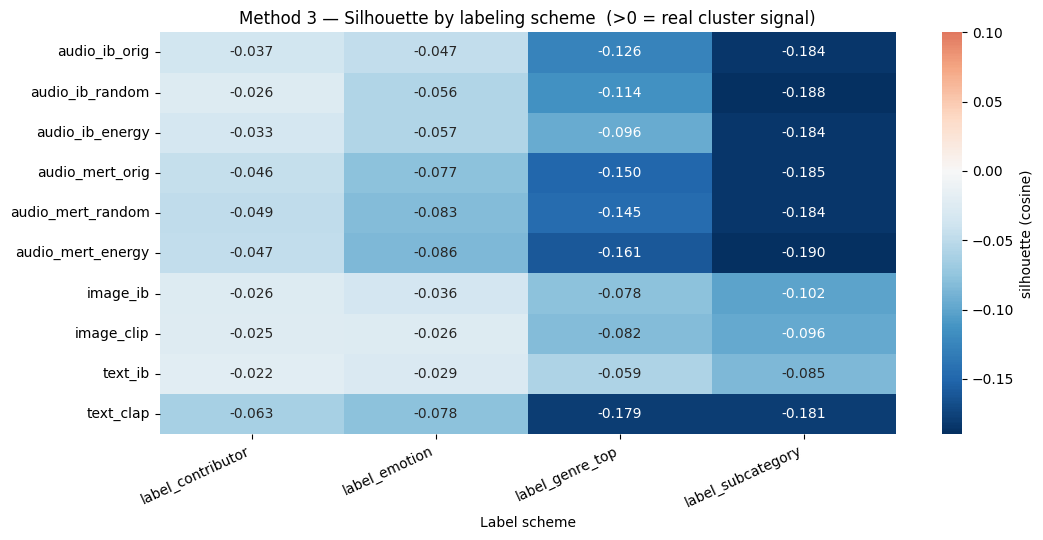


Best labeling per encoder (highest silhouette):
  audio_ib_orig          → label_contributor         silhouette = -0.037
  audio_ib_random        → label_contributor         silhouette = -0.026
  audio_ib_energy        → label_contributor         silhouette = -0.033
  audio_mert_orig        → label_contributor         silhouette = -0.046
  audio_mert_random      → label_contributor         silhouette = -0.049
  audio_mert_energy      → label_contributor         silhouette = -0.047
  image_ib               → label_contributor         silhouette = -0.026
  image_clip             → label_contributor         silhouette = -0.025
  text_ib                → label_contributor         silhouette = -0.022
  text_clap              → label_contributor         silhouette = -0.063


In [10]:
# === CELL 10 — METHOD 3: Silhouette by alternative labelings ===
# For each encoder × label scheme, compute silhouette (cosine, on L2-normalized).
# Whichever labeling gives the highest silhouette is what the encoder is genuinely
# organizing by.
import os, numpy as np, pandas as pd
from sklearn.metrics import silhouette_score

rows = []
for enc in ENCODERS:
    Xn = l2(EMB[enc])
    for lab in LABEL_COLS:
        codes = metadata[lab].astype("category").cat.codes.values
        if metadata[lab].nunique() < 2:
            continue
        try:
            s = silhouette_score(Xn, codes, metric="cosine")
        except Exception:
            s = np.nan
        rows.append({"encoder": enc, "label": lab, "silhouette": round(s, 4)})

m3 = pd.DataFrame(rows)
m3_pivot = m3.pivot(index="encoder", columns="label", values="silhouette").loc[ENCODERS]
m3.to_csv(os.path.join(RES_OUT, "method3_silhouette_heatmap.csv"), index=False)

import matplotlib.pyplot as plt, seaborn as sns
vmax = max(0.10, m3_pivot.values.max())
vmin = min(-0.02, m3_pivot.values.min())
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.heatmap(m3_pivot, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
            vmin=vmin, vmax=vmax, cbar_kws={"label": "silhouette (cosine)"}, ax=ax)
ax.set_title("Method 3 — Silhouette by labeling scheme  (>0 = real cluster signal)")
ax.set_ylabel(""); ax.set_xlabel("Label scheme")
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
fig.savefig(os.path.join(FIG_OUT, "method3_silhouette_heatmap.png"), dpi=150)
plt.show()

print("\nBest labeling per encoder (highest silhouette):")
for enc in ENCODERS:
    sub = m3[m3.encoder == enc].sort_values("silhouette", ascending=False)
    if not sub.empty:
        top = sub.iloc[0]
        print(f"  {enc:22s} → {top.label:25s} silhouette = {top.silhouette:+.3f}")


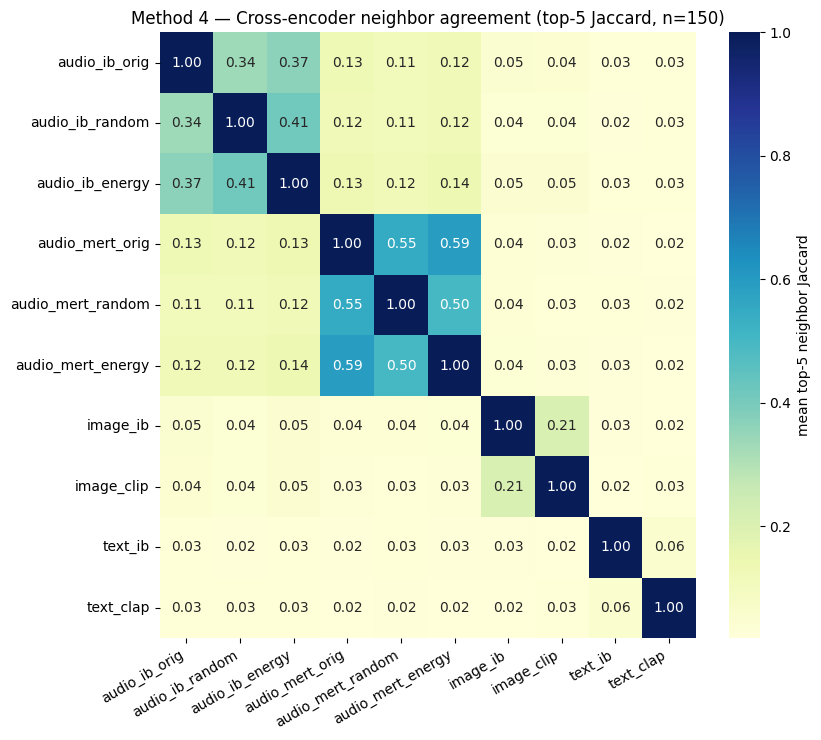


Top-10 most-disagreed tracks per encoder pair:

  audio_ib_orig vs audio_ib_energy
     [ 1]  J=0.00  track_005  ':) '  (Vital & Jo / Pop)
     [ 2]  J=0.00  track_013  'Anchor'  (Dreaminess / Folk)
     [ 3]  J=0.00  track_016  'Another Day of Sun'  (Vital & Jo / Jazz)
     [ 4]  J=0.00  track_093  'Myth'  (Dreaminess / Pop)
     [ 5]  J=0.00  track_096  'Nothing'  (Tender & I / Folk)
     [ 6]  J=0.00  track_111  'Run to me'  (Tender & I / Pop)
     [ 7]  J=0.00  track_132  'Thinking Clean'  (Dreaminess / R&B)
     [ 8]  J=0.11  track_019  'Bad Guy'  (Tension, T / Pop)
     [ 9]  J=0.11  track_022  'Believer'  (Tension, T / Rock)
     [10]  J=0.11  track_026  'Bloody Samaritan (Remix)'  (Vital & Jo / Pop)

  audio_ib_orig vs audio_ib_random
     [ 1]  J=0.00  track_007  'A Trick of the light'  (Dreaminess / Folk)
     [ 2]  J=0.00  track_010  'Air Supply'  (Dreaminess / Rock)
     [ 3]  J=0.00  track_016  'Another Day of Sun'  (Vital & Jo / Jazz)
     [ 4]  J=0.00  track_029  'By Th

In [11]:
# === CELL 11 — METHOD 4: Cross-encoder disagreement (neighbor-Jaccard) ===
# For each pair of encoders, compute per-track Jaccard between their top-K
# nearest-neighbor sets.  Low Jaccard = the two encoders see different
# neighborhoods for that track.
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

K_NB = 5

# Pre-compute neighbor sets for each encoder
NB_SETS = {enc: [set(row) for row in topk_neighbors(EMB[enc], k=K_NB, exclude_self=True)]
           for enc in ENCODERS}

# Pairwise mean Jaccard heatmap
M = np.zeros((len(ENCODERS), len(ENCODERS)))
for a, ea in enumerate(ENCODERS):
    for b, eb in enumerate(ENCODERS):
        if b < a: continue
        scores = [len(NB_SETS[ea][i] & NB_SETS[eb][i]) /
                  max(1, len(NB_SETS[ea][i] | NB_SETS[eb][i]))
                  for i in range(N)]
        M[a, b] = M[b, a] = np.mean(scores)

dis = pd.DataFrame(M, index=ENCODERS, columns=ENCODERS).round(3)
dis.to_csv(os.path.join(RES_OUT, "method4_jaccard_matrix.csv"))

fig, ax = plt.subplots(figsize=(8.5, 7.5))
sns.heatmap(dis, annot=True, fmt=".2f", cmap="YlGnBu",
            cbar_kws={"label": f"mean top-{K_NB} neighbor Jaccard"}, ax=ax)
ax.set_title(f"Method 4 — Cross-encoder neighbor agreement (top-{K_NB} Jaccard, n=150)")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
fig.savefig(os.path.join(FIG_OUT, "method4_jaccard_heatmap.png"), dpi=150)
plt.show()

# Top-K most-disagreed tracks per pair (pairs of interest)
PAIRS = [("audio_ib_orig","audio_mert_orig"),
         ("audio_ib_orig","audio_ib_random"),
         ("audio_ib_orig","audio_ib_energy"),
         ("image_ib","image_clip"),
         ("text_ib","text_clap")]
disag_top = []
for ea, eb in PAIRS:
    if ea not in ENCODERS or eb not in ENCODERS: continue
    per_track = []
    for i in range(N):
        j = len(NB_SETS[ea][i] & NB_SETS[eb][i]) / max(1, len(NB_SETS[ea][i] | NB_SETS[eb][i]))
        per_track.append((i, j))
    per_track.sort(key=lambda x: x[1])
    for rank, (i, j) in enumerate(per_track[:10], start=1):
        md = metadata.iloc[i]
        disag_top.append({
            "pair": f"{ea} vs {eb}", "rank": rank, "jaccard": round(j, 3),
            "track_id": md.track_id, "song": md.song_title,
            "emotion": md.label_emotion, "genre": md.label_genre_top,
        })
disag_df = pd.DataFrame(disag_top)
disag_df.to_csv(os.path.join(RES_OUT, "method4_disagreement_topK.csv"), index=False)
print("\nTop-10 most-disagreed tracks per encoder pair:")
for pair, sub in disag_df.groupby("pair"):
    print(f"\n  {pair}")
    for _, r in sub.iterrows():
        print(f"     [{r['rank']:2d}]  J={r.jaccard:.2f}  {r.track_id}  '{r.song[:30]}'  "
              f"({r.emotion[:10]} / {r.genre[:10]})")


In [12]:
# === CELL 12 — METHOD 5: Block-sorted 150×150 similarity heatmaps ===
# For each encoder, render the 150x150 cosine matrix sorted by each label
# scheme. The label that gives the cleanest block-diagonal is what that
# encoder is most strongly responding to.
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

# Compute "block contrast" for each (encoder × label): mean within-block cosine
# minus mean between-block cosine. Bigger = stronger block-diagonal structure.
def block_contrast(sim, codes):
    """sim is (N,N) cosine; codes is (N,) int labels."""
    in_mask  = (codes[:, None] == codes[None, :]).astype(bool)
    np.fill_diagonal(in_mask, False)         # exclude self-pairs
    out_mask = ~in_mask
    np.fill_diagonal(out_mask, False)
    in_mean  = sim[in_mask].mean()  if in_mask.any()  else np.nan
    out_mean = sim[out_mask].mean() if out_mask.any() else np.nan
    return in_mean, out_mean, in_mean - out_mean

# Pick which encoders to RENDER (avoid 60-figure explosion). All encoders are
# scored, but we only render heatmaps for a curated short list.
RENDER_ENC = ["audio_ib_orig", "audio_mert_orig", "image_ib", "image_clip", "text_ib"]
RENDER_ENC = [e for e in RENDER_ENC if e in ENCODERS]

scores = []
for enc in ENCODERS:
    sim = cos_sim(EMB[enc])
    for lab in LABEL_COLS:
        codes = metadata[lab].astype("category").cat.codes.values
        if metadata[lab].nunique() < 2: continue
        ib, ob, contrast = block_contrast(sim, codes)
        scores.append({"encoder": enc, "label": lab,
                       "within_block_mean": round(ib, 4),
                       "between_block_mean": round(ob, 4),
                       "block_contrast": round(contrast, 4)})

m5 = pd.DataFrame(scores)
m5.to_csv(os.path.join(RES_OUT, "method5_blocksort_summary.csv"), index=False)

# Render block-sorted heatmaps for the curated encoders × all labels
for enc in RENDER_ENC:
    sim = cos_sim(EMB[enc])
    fig, axes = plt.subplots(2, 3, figsize=(14, 9))
    fig.suptitle(f"Method 5 — Block-sorted cosine matrix · encoder = {enc}", fontsize=13)
    for ax, lab in zip(axes.flat, LABEL_COLS):
        if metadata[lab].nunique() < 2:
            ax.axis("off"); continue
        order = np.argsort(metadata[lab].astype("category").cat.codes.values)
        block = sim[np.ix_(order, order)]
        sns.heatmap(block, ax=ax, cmap="viridis", cbar=False, square=True,
                    xticklabels=False, yticklabels=False,
                    vmin=np.percentile(block, 5), vmax=np.percentile(block, 95))
        sub = m5[(m5.encoder == enc) & (m5.label == lab)].iloc[0]
        ax.set_title(f"{lab.replace('label_','')}  (Δ = {sub.block_contrast:+.3f})", fontsize=10)
    for ax in axes.flat[len(LABEL_COLS):]:
        ax.axis("off")
    plt.tight_layout()
    fig.savefig(os.path.join(FIG_OUT, f"method5_blocksort_{enc}.png"), dpi=130, bbox_inches='tight')
    plt.show()
    plt.close()

# Best label per encoder by block contrast
print("\nBest labeling per encoder by block contrast:")
for enc in ENCODERS:
    sub = m5[m5.encoder == enc].sort_values("block_contrast", ascending=False)
    if not sub.empty:
        top = sub.iloc[0]
        print(f"  {enc:22s} → {top.label:25s}  Δ={top.block_contrast:+.3f}  "
              f"(within={top.within_block_mean:+.3f}  between={top.between_block_mean:+.3f})")


Output hidden; open in https://colab.research.google.com to view.

In [13]:
# === CELL 13 — Cross-method summary + write summary.md ===
import os, pandas as pd, numpy as np

# Reload everything from disk so this cell is independently re-runnable
m1 = pd.read_csv(os.path.join(RES_OUT, "method1_kmeans_purity.csv"))
m3 = pd.read_csv(os.path.join(RES_OUT, "method3_silhouette_heatmap.csv"))
m4 = pd.read_csv(os.path.join(RES_OUT, "method4_jaccard_matrix.csv"), index_col=0)
m5 = pd.read_csv(os.path.join(RES_OUT, "method5_blocksort_summary.csv"))

lines = []
lines.append(f"# Exploration run · {RUN_STAMP}")
lines.append("")
lines.append(f"- N tracks: **{N}**")
lines.append(f"- Encoder spaces analysed: **{len(ENCODERS)}**  ({', '.join(ENCODERS)})")
lines.append(f"- Label schemes: **{len(LABEL_COLS)}**  ({', '.join(c.replace('label_','') for c in LABEL_COLS)})")
lines.append(f"- Re-extraction: **{'enabled' if RUN_REEXTRACT else 'disabled'}**  (K=5 clips per track)")
lines.append("")

# 1. What does each encoder organize by? (silhouette + block contrast vote)
lines.append("## What does each encoder actually organize by?")
lines.append("Per encoder, we report the top label scheme by silhouette and by block contrast.  When both methods agree, that's a strong signal.")
lines.append("")
lines.append("| Encoder | Top label by silhouette | silhouette | Top label by block contrast | Δ |")
lines.append("|---|---|---|---|---|")
for enc in ENCODERS:
    s_top = m3[m3.encoder == enc].sort_values("silhouette", ascending=False).iloc[0]
    b_top = m5[m5.encoder == enc].sort_values("block_contrast", ascending=False).iloc[0]
    lines.append(f"| `{enc}` | {s_top.label.replace('label_','')} | {s_top.silhouette:+.3f} | "
                 f"{b_top.label.replace('label_','')} | {b_top.block_contrast:+.3f} |")
lines.append("")

# 2. Did re-sampling change things?
if RUN_REEXTRACT:
    lines.append("## Did the new audio sampling change anything?")
    lines.append("Compare the silhouette by emotion across the three audio_ib variants and three audio_mert variants:")
    lines.append("")
    for fam in ["audio_ib", "audio_mert"]:
        variants = [e for e in ENCODERS if e.startswith(fam)]
        if len(variants) < 2: continue
        lines.append(f"### {fam}")
        lines.append("| Variant | silhouette by emotion | silhouette by genre_top | Δ block-contrast emotion |")
        lines.append("|---|---|---|---|")
        for v in variants:
            se = m3[(m3.encoder == v) & (m3.label == "label_emotion")].iloc[0].silhouette
            sg = m3[(m3.encoder == v) & (m3.label == "label_genre_top")].iloc[0].silhouette
            be = m5[(m5.encoder == v) & (m5.label == "label_emotion")].iloc[0].block_contrast
            lines.append(f"| `{v}` | {se:+.3f} | {sg:+.3f} | {be:+.3f} |")
        lines.append("")

# 3. Does ANY modality match emotion labels?
lines.append("## Does any modality align with our subjective emotional labeling?")
emo = m3[m3.label == "label_emotion"].sort_values("silhouette", ascending=False)
lines.append("| Encoder | silhouette by emotion |")
lines.append("|---|---|")
for _, r in emo.iterrows():
    lines.append(f"| `{r.encoder}` | {r.silhouette:+.3f} |")
lines.append("")
top_emo = emo.iloc[0]
lines.append(f"**Best encoder for emotion: `{top_emo.encoder}` with silhouette {top_emo.silhouette:+.3f}.**")
ref = 0.10
verdict = "✅ meaningful cluster signal" if top_emo.silhouette > ref else (
          "⚠ weak signal — close to random" if top_emo.silhouette > 0 else
          "❌ no meaningful clustering by emotion")
lines.append(f"Interpretation: {verdict} (rule of thumb: silhouette > 0.10 = real clustering, > 0.25 = strong).")
lines.append("")

# 4. Which pairs of encoders disagree most about neighborhoods?
lines.append("## Cross-encoder disagreement (top-5 neighbor Jaccard)")
lines.append("Lower = encoders see different things.")
lines.append("")
flat = []
encs = m4.index.tolist()
for i, a in enumerate(encs):
    for b in encs[i+1:]:
        flat.append((a, b, m4.loc[a, b]))
flat.sort(key=lambda x: x[2])
lines.append("| Encoder pair | Jaccard |")
lines.append("|---|---|")
for a, b, j in flat[:10]:
    lines.append(f"| `{a}`  ×  `{b}` | {j:.2f} |")
lines.append("")

# 5. Files index
lines.append("## Output files in this run")
for sub in ("embeddings", "results", "figures"):
    lines.append(f"### `{sub}/`")
    p = os.path.join(RUN_DIR, sub)
    for f in sorted(os.listdir(p)):
        lines.append(f"- `{f}`")
    lines.append("")

summary_path = os.path.join(RUN_DIR, "summary.md")
with open(summary_path, "w") as f:
    f.write("\n".join(lines))
print(f"\n💾 wrote {summary_path}")
print()
print("\n".join(lines[:30]))
print("\n…(truncated, see summary.md for full report)")



💾 wrote /content/drive/MyDrive/DL_Project_2026/Explorations/run_2026-05-05_14-38/summary.md

# Exploration run · 2026-05-05_14-38

- N tracks: **150**
- Encoder spaces analysed: **10**  (audio_ib_orig, audio_ib_random, audio_ib_energy, audio_mert_orig, audio_mert_random, audio_mert_energy, image_ib, image_clip, text_ib, text_clap)
- Label schemes: **6**  (emotion, subcategory, contributor, genre_top, vocal, duration_bucket)
- Re-extraction: **enabled**  (K=5 clips per track)

## What does each encoder actually organize by?
Per encoder, we report the top label scheme by silhouette and by block contrast.  When both methods agree, that's a strong signal.

| Encoder | Top label by silhouette | silhouette | Top label by block contrast | Δ |
|---|---|---|---|---|
| `audio_ib_orig` | contributor | -0.037 | genre_top | +0.085 |
| `audio_ib_random` | contributor | -0.026 | genre_top | +0.081 |
| `audio_ib_energy` | contributor | -0.033 | genre_top | +0.090 |
| `audio_mert_orig` | contributor |

## Next steps

* **Inspect `summary.md`** — top-line answer to the "what does each encoder
  group by" question lives there.
* **Run the notebook a second time with a different `SEED`** in Cell 1 to
  see how stable the random-K-mean audio embedding is across runs.
* **Compare `audio_ib_orig` vs `audio_ib_random` vs `audio_ib_energy`** rows
  in the silhouette / k-means / block-contrast tables — if energy-peak
  sampling improves silhouette by emotion, the original mid-clip approach
  was missing the genre-defining sections of the song.
* **Open `results/method2_diagnostic_neighbors.txt`** to see, for the five
  diagnostic tracks, exactly which neighbors each encoder pulls — the most
  intuitive evidence of "what each encoder is really doing".
* **Open `figures/method5_blocksort_*.png`** — if the `genre_top` panel has
  a much cleaner block-diagonal than the `emotion` panel, that encoder is
  organizing by genre, not by emotion.
